# Análise Individual: Vendedor

Este notebook apresenta uma análise exploratória com foco no desempenho dos vendedores da base Olist.  
A análise utiliza o dataset tratado `olist_super_dataset.csv`, gerado a partir do pipeline de ETL do projeto.

**Arquivo fonte:** `../data/processed/olist_super_dataset.csv`

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)
pd.options.display.float_format = "{:,.2f}".format

## 1. Carregamento e preparação dos dados

In [19]:
df = pd.read_csv("../data/processed/olist_super_dataset.csv")

colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for col in colunas_data:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df_vendedores = df[df["seller_id"].notna()].copy()

print(f"Shape do dataset completo: {df.shape}")
print(f"Shape do recorte com seller_id válido: {df_vendedores.shape}")
print(f"Quantidade de vendedores únicos: {df_vendedores['seller_id'].nunique()}")

df_vendedores.head()

Shape do dataset completo: (111744, 32)
Shape do recorte com seller_id válido: (111741, 32)
Quantidade de vendedores únicos: 2986


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,tempo_entrega_dias,atraso_entrega,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value,review_score,receita_liquida
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.00,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,38.71,4.00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.00,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,141.46,4.00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.00,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,179.12,5.00,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.00,False,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop,72.20,5.00,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.00,False,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery,28.62,5.00,28.62


Análise inicial: o recorte considera apenas registros com `seller_id` preenchido, garantindo consistência para as análises de desempenho dos vendedores. A base já contém métricas de receita, avaliação e logística, o que permite construir uma análise completa sem voltar aos CSVs brutos.

## 2. Dados trabalhados e EDA inicial

In [20]:
colunas_principais = [
    "seller_id", "order_id", "price", "freight_value", "payment_value",
    "review_score", "tempo_entrega_dias", "atraso_entrega", "receita_liquida"
]

display(df_vendedores[colunas_principais].head())

display(df_vendedores[colunas_principais].describe(include="all").T)

display(df_vendedores.isnull().sum().sort_values(ascending=False).head(15))

,seller_id,order_id,price,freight_value,payment_value,review_score,tempo_entrega_dias,atraso_entrega,receita_liquida
0,3504c0cb71d7fa48d967e0e4c94d59d9,e481f51cbdc54678b7cc49136f2d6af7,29.99,8.72,38.71,4.00,8.00,False,38.71
1,289cdb325fb7e7f891c38608bf9e0962,53cdb2fc8bc7dce0b6741e2150273451,118.70,22.76,141.46,4.00,13.00,False,141.46
2,4869f7a5dfa277a7dca6462dcf3b52b2,47770eb9100c2d0c44946d9cf07ec65d,159.90,19.22,179.12,5.00,9.00,False,179.12
3,66922902710d126a0e7d26b0e3805106,949d5b44dbf5de918fe9c16f97b45f8a,45.00,27.20,72.20,5.00,13.00,False,72.20
4,2c9e548be18521d1c43cde1c582c6de8,ad21c59c0840e6cb83a9ceb5573f8159,19.90,8.72,28.62,5.00,2.00,False,28.62


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,111741,2986,6560211a19b47992c3666cc44a7e94c0,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,111741,97896,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"111,741.00",NaN,NaN,NaN,120.22,182.58,0.85,39.90,74.90,134.90,"6,735.00"
freight_value,"111,741.00",NaN,NaN,NaN,19.98,15.75,0.00,13.08,16.27,21.15,409.68
payment_value,"111,738.00",NaN,NaN,NaN,179.49,270.76,9.59,65.60,114.34,194.99,"13,664.08"
review_score,"110,822.00",NaN,NaN,NaN,4.05,1.37,1.00,4.00,5.00,5.00,5.00
tempo_entrega_dias,"110,189.00",NaN,NaN,NaN,12.01,9.45,0.00,6.00,10.00,15.00,209.00
atraso_entrega,111741,2,False,103027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
receita_liquida,"111,741.00",NaN,NaN,NaN,140.20,189.63,6.08,55.22,92.21,157.68,"6,929.31"


product_category_name            1576
product_name_lenght              1576
product_description_lenght       1576
product_photos_qty               1576
order_delivered_customer_date    1552
tempo_entrega_dias               1552
review_score                      919
order_delivered_carrier_date      361
product_height_cm                  18
product_weight_g                   18
product_length_cm                  18
product_width_cm                   18
order_approved_at                  15
payment_value                       3
order_purchase_timestamp            0
dtype: int64

Análise: as métricas centrais para o recorte de vendedores são receita, volume de pedidos, review score, tempo de entrega e taxa de atraso. Esse conjunto é suficiente para avaliar desempenho comercial e operacional de forma integrada.

## 3. KPIs gerais do recorte de vendedores

In [21]:
qtd_vendedores = df_vendedores["seller_id"].nunique()
qtd_pedidos = df_vendedores["order_id"].nunique()
receita_total = df_vendedores["receita_liquida"].sum()
ticket_medio_pedido = df_vendedores.groupby("order_id")["receita_liquida"].sum().mean()
avaliacao_media = df_vendedores["review_score"].mean()
tempo_medio_entrega = df_vendedores["tempo_entrega_dias"].mean()
percentual_atraso = df_vendedores["atraso_entrega"].mean() * 100

print("Resumo de KPIs - Vendedores")
print(f"Quantidade de vendedores únicos: {qtd_vendedores}")
print(f"Quantidade de pedidos: {qtd_pedidos}")
print(f"Receita total: R$ {receita_total:,.2f}")
print(f"Ticket médio por pedido: R$ {ticket_medio_pedido:,.2f}")
print(f"Avaliação média: {avaliacao_media:.2f}")
print(f"Tempo médio de entrega: {tempo_medio_entrega:.2f} dias")
print(f"Percentual de pedidos com atraso: {percentual_atraso:.2f}%")

Resumo de KPIs - Vendedores
Quantidade de vendedores únicos: 2986
Quantidade de pedidos: 97896
Receita total: R$ 15,665,891.84
Ticket médio por pedido: R$ 160.03
Avaliação média: 4.05
Tempo médio de entrega: 12.01 dias
Percentual de pedidos com atraso: 7.80%


Análise: o desempenho geral dos vendedores deve ser lido por três dimensões complementares: resultado financeiro, eficiência operacional e satisfação do cliente. Os próximos blocos exploram essas dimensões de forma comparativa.

## 4. Ranking dos vendedores com maior receita

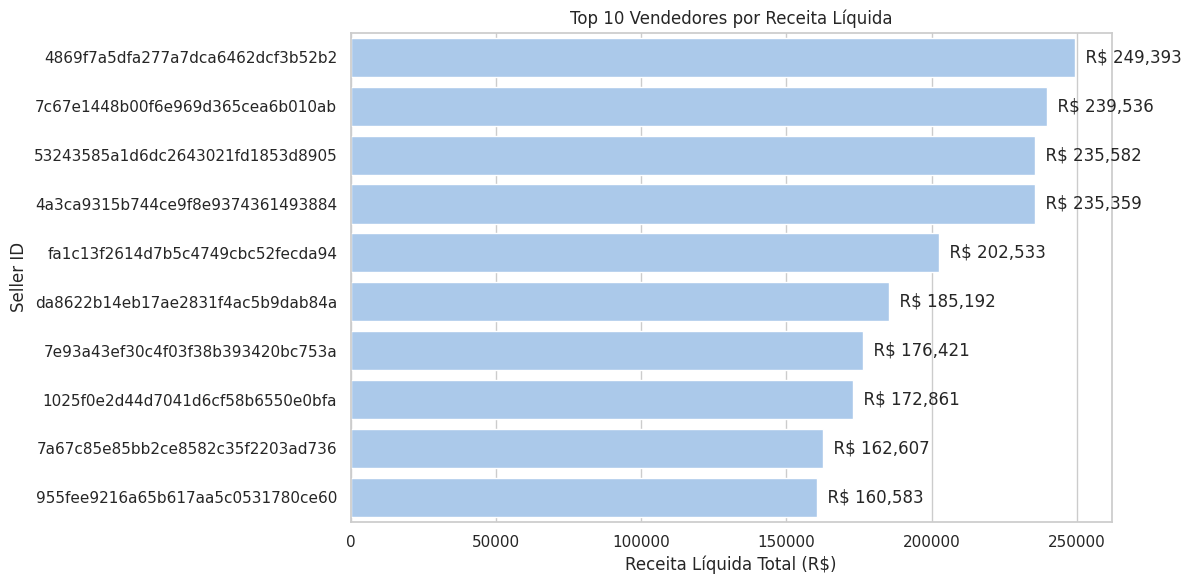

In [22]:
top_vendedores_receita = (
    df_vendedores.groupby("seller_id")["receita_liquida"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_vendedores_receita.values,
    y=top_vendedores_receita.index
)
plt.title("Top 10 Vendedores por Receita Líquida")
plt.xlabel("Receita Líquida Total (R$)")
plt.ylabel("Seller ID")

for i, v in enumerate(top_vendedores_receita.values):
    ax.text(v, i, f"  R$ {v:,.0f}", va="center")

plt.tight_layout()
plt.show()

Insight: a receita está concentrada em um grupo pequeno de vendedores. Esse comportamento é típico de marketplaces e sugere assimetria operacional entre os sellers.

## 5. Ranking dos vendedores com maior volume de pedidos

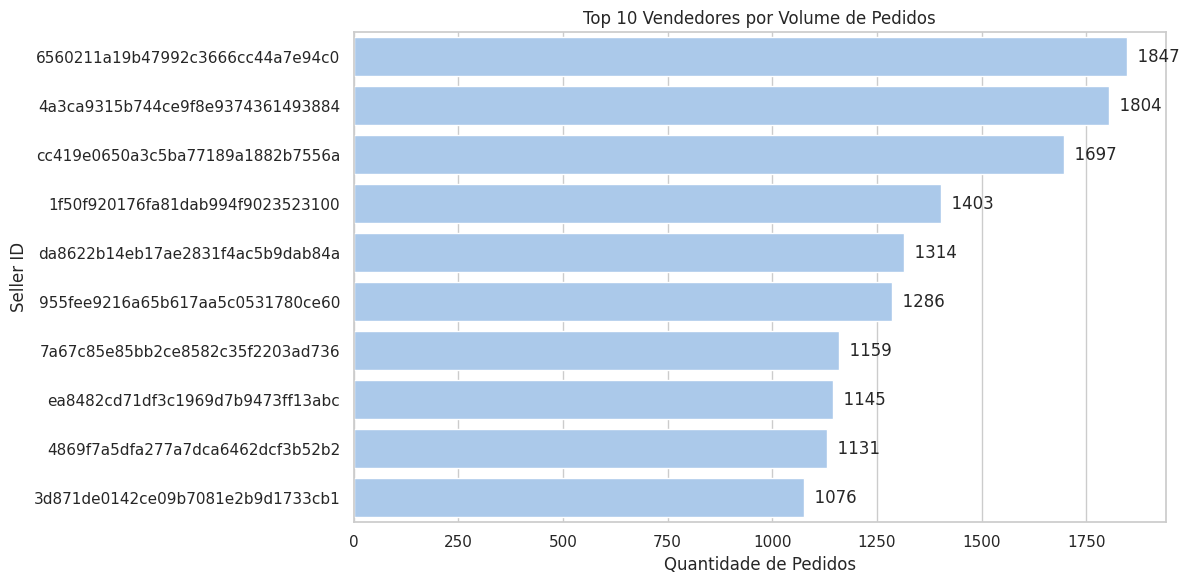

In [23]:
top_vendedores_pedidos = (
    df_vendedores.groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_vendedores_pedidos.values,
    y=top_vendedores_pedidos.index
)
plt.title("Top 10 Vendedores por Volume de Pedidos")
plt.xlabel("Quantidade de Pedidos")
plt.ylabel("Seller ID")

for i, v in enumerate(top_vendedores_pedidos.values):
    ax.text(v, i, f"  {int(v)}", va="center")

plt.tight_layout()
plt.show()

Insight: nem sempre os vendedores com maior volume são os mesmos com maior receita. A comparação entre receita e volume ajuda a diferenciar sellers de alto ticket daqueles com operação mais escalável.

## 6. Avaliação média dos vendedores com maior volume

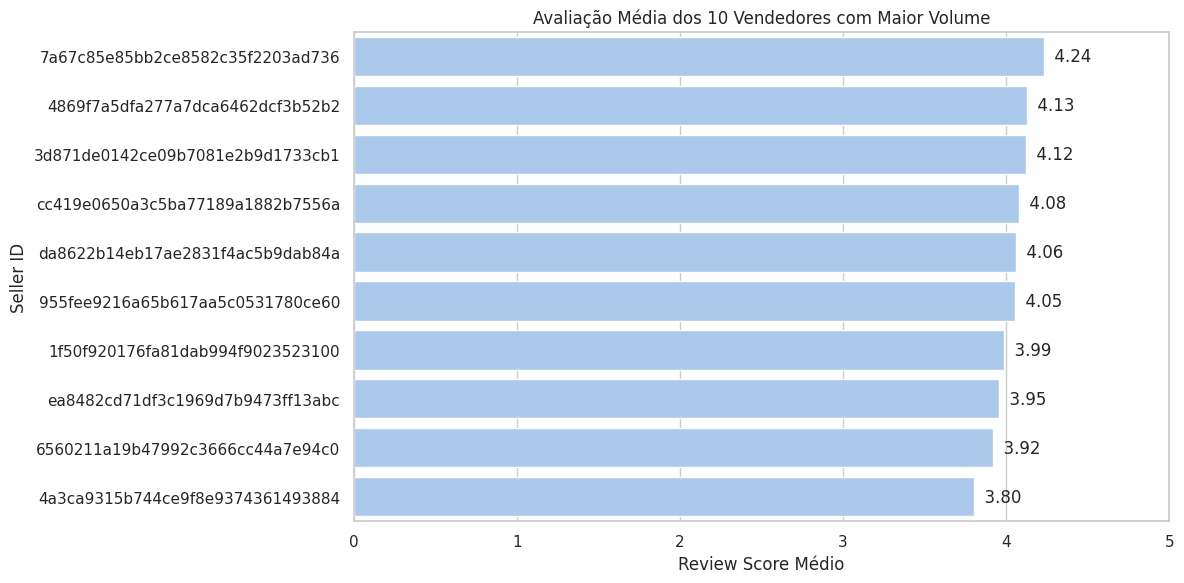

In [24]:
top_10_volume_ids = top_vendedores_pedidos.index

avaliacao_top_volume = (
    df_vendedores[df_vendedores["seller_id"].isin(top_10_volume_ids)]
    .groupby("seller_id")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=avaliacao_top_volume.values,
    y=avaliacao_top_volume.index
)

plt.title("Avaliação Média dos 10 Vendedores com Maior Volume")
plt.xlabel("Review Score Médio")
plt.ylabel("Seller ID")
plt.xlim(0, 5)

for i, v in enumerate(avaliacao_top_volume.values):
    ax.text(v, i, f"  {v:.2f}", va="center")

plt.tight_layout()
plt.show()

Insight: a análise mostra se a escala operacional está sendo acompanhada por boa experiência do cliente. Vendedores de grande porte podem manter boa avaliação, mas isso precisa ser confirmado empiricamente.

## 7. Eficiência logística dos vendedores com maior volume

In [25]:
logistica_top_volume = (
    df_vendedores[df_vendedores["seller_id"].isin(top_10_volume_ids)]
    .groupby("seller_id")
    .agg(
        tempo_medio_entrega=("tempo_entrega_dias", "mean"),
        taxa_atraso=("atraso_entrega", "mean")
    )
)

logistica_top_volume["taxa_atraso_pct"] = logistica_top_volume["taxa_atraso"] * 100

display(logistica_top_volume.sort_values("tempo_medio_entrega", ascending=False))

,tempo_medio_entrega,taxa_atraso,taxa_atraso_pct
seller_id,,,
1f50f920176fa81dab994f9023523100,15.11,0.09,9.43
4869f7a5dfa277a7dca6462dcf3b52b2,14.55,0.12,11.52
4a3ca9315b744ce9f8e9374361493884,13.94,0.11,10.78
3d871de0142ce09b7081e2b9d1733cb1,12.96,0.06,5.86
ea8482cd71df3c1969d7b9473ff13abc,12.85,0.10,10.23
cc419e0650a3c5ba77189a1882b7556a,11.06,0.06,5.83
da8622b14eb17ae2831f4ac5b9dab84a,10.70,0.07,7.29
7a67c85e85bb2ce8582c35f2203ad736,10.69,0.06,5.81
955fee9216a65b617aa5c0531780ce60,10.30,0.08,7.94


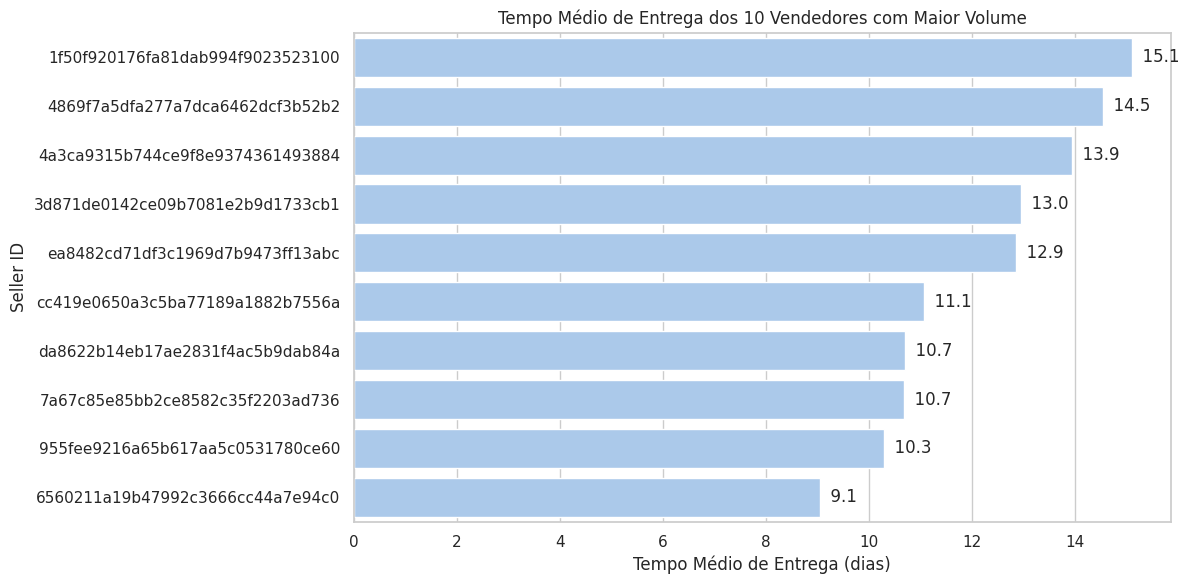

In [26]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=logistica_top_volume.sort_values("tempo_medio_entrega", ascending=False).reset_index(),
    x="tempo_medio_entrega",
    y="seller_id"
)
plt.title("Tempo Médio de Entrega dos 10 Vendedores com Maior Volume")
plt.xlabel("Tempo Médio de Entrega (dias)")
plt.ylabel("Seller ID")

for i, v in enumerate(logistica_top_volume.sort_values("tempo_medio_entrega", ascending=False)["tempo_medio_entrega"].values):
    ax.text(v, i, f"  {v:.1f}", va="center")

plt.tight_layout()
plt.show()

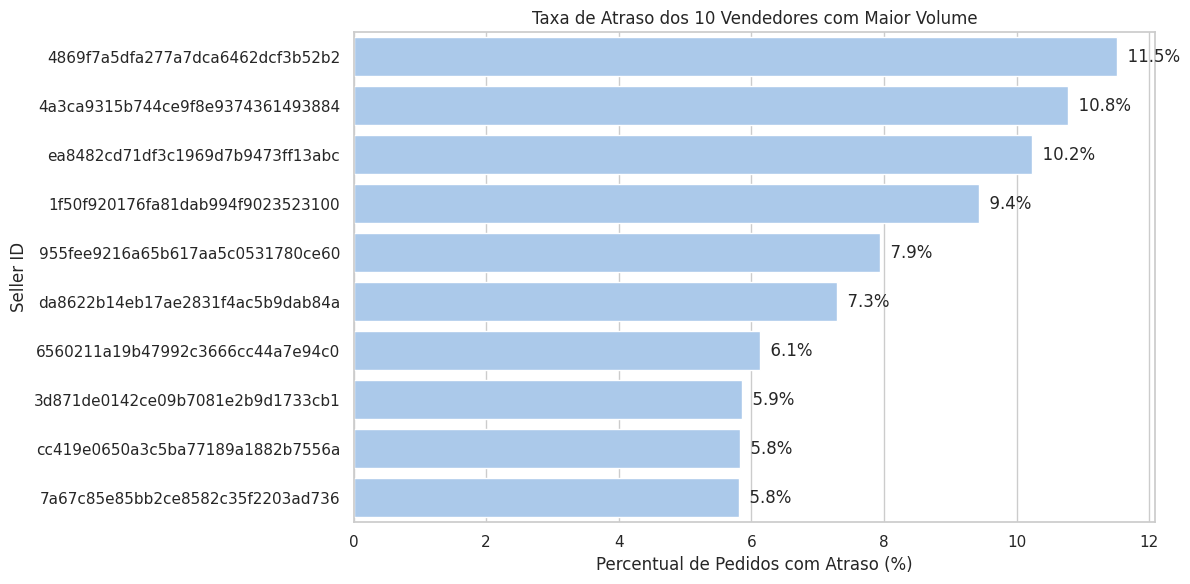

In [27]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=logistica_top_volume.sort_values("taxa_atraso_pct", ascending=False).reset_index(),
    x="taxa_atraso_pct",
    y="seller_id"
)
plt.title("Taxa de Atraso dos 10 Vendedores com Maior Volume")
plt.xlabel("Percentual de Pedidos com Atraso (%)")
plt.ylabel("Seller ID")

for i, v in enumerate(logistica_top_volume.sort_values("taxa_atraso_pct", ascending=False)["taxa_atraso_pct"].values):
    ax.text(v, i, f"  {v:.1f}%", va="center")

plt.tight_layout()
plt.show()

Insight: vendedores com maior volume não são homogêneos do ponto de vista logístico. Alguns conseguem operar em escala com menor atraso, enquanto outros apresentam gargalos mais visíveis.

## 8. Correlações com outros parâmetros relacionados

In [28]:
base_correlacao = (
    df_vendedores.groupby("seller_id")
    .agg(
        receita_total=("receita_liquida", "sum"),
        pedidos=("order_id", "nunique"),
        frete_medio=("freight_value", "mean"),
        review_medio=("review_score", "mean"),
        entrega_media=("tempo_entrega_dias", "mean"),
        taxa_atraso=("atraso_entrega", "mean")
    )
    .dropna()
)

base_correlacao["taxa_atraso_pct"] = base_correlacao["taxa_atraso"] * 100

corr_plot = base_correlacao[[
    "receita_total",
    "pedidos",
    "review_medio",
    "entrega_media",
    "taxa_atraso"
]].corr()

corr_plot

,receita_total,pedidos,review_medio,entrega_media,taxa_atraso
receita_total,1.00,0.83,-0.02,0.04,-0.00
pedidos,0.83,1.00,-0.02,0.01,-0.01
review_medio,-0.02,-0.02,1.00,-0.39,-0.41
entrega_media,0.04,0.01,-0.39,1.00,0.54
taxa_atraso,-0.00,-0.01,-0.41,0.54,1.00


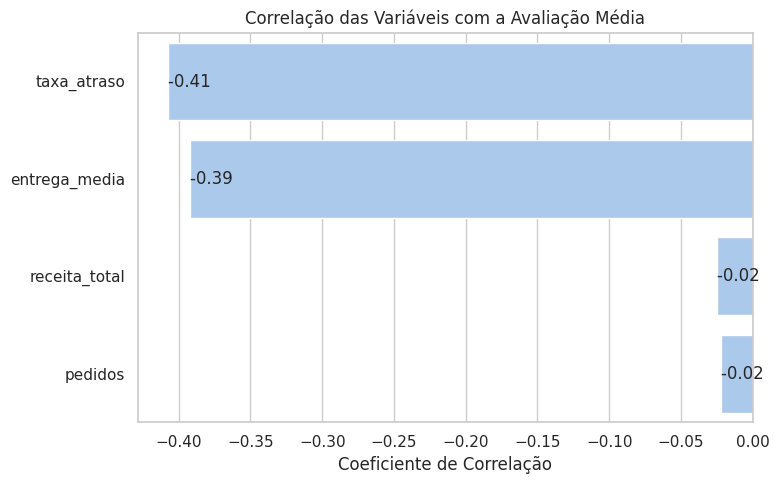

In [29]:
corr_review = corr_plot["review_medio"].drop("review_medio").sort_values()

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=corr_review.values,
    y=corr_review.index
)

plt.title("Correlação das Variáveis com a Avaliação Média")
plt.xlabel("Coeficiente de Correlação")
plt.ylabel("")

for i, v in enumerate(corr_review.values):
    ax.text(v, i, f"  {v:.2f}" if v >= 0 else f"{v:.2f}  ", va="center")

plt.tight_layout()
plt.show()

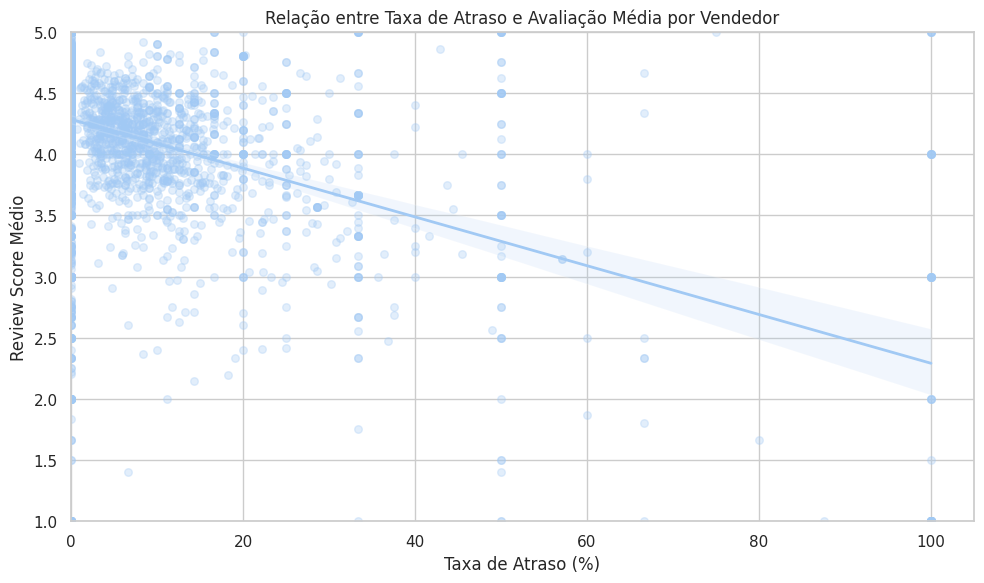

In [30]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=base_correlacao,
    x="taxa_atraso_pct",
    y="review_medio",
    scatter_kws={"alpha": 0.30, "s": 30},
    line_kws={"linewidth": 2}
)

plt.title("Relação entre Taxa de Atraso e Avaliação Média por Vendedor")
plt.xlabel("Taxa de Atraso (%)")
plt.ylabel("Review Score Médio")
plt.xlim(left=0)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

Insight técnico: a relação entre atraso e avaliação é negativa. O gráfico simplificado e a correlação reforçam que pior desempenho logístico tende a reduzir a satisfação média do cliente.

## 9. Agrupamento por faixas de receita

In [31]:
base_correlacao["faixa_receita"] = pd.qcut(
    base_correlacao["receita_total"],
    q=4,
    labels=["Baixa", "Média-Baixa", "Média-Alta", "Alta"],
    duplicates="drop"
)

resumo_faixas = (
    base_correlacao.groupby("faixa_receita", observed=False)
    .agg(
        vendedores=("receita_total", "count"),
        receita_media=("receita_total", "mean"),
        pedidos_medios=("pedidos", "mean"),
        review_medio=("review_medio", "mean"),
        entrega_media=("entrega_media", "mean"),
        taxa_atraso_media=("taxa_atraso", "mean")
    )
)

resumo_faixas["taxa_atraso_media"] = resumo_faixas["taxa_atraso_media"] * 100
resumo_faixas

,vendedores,receita_media,pedidos_medios,review_medio,entrega_media,taxa_atraso_media
faixa_receita,,,,,,
Baixa,742,141.35,1.80,4.15,11.19,8.11
Média-Baixa,741,615.13,5.59,4.19,11.17,8.01
Média-Alta,741,"2,165.53",15.37,4.10,12.02,8.34
Alta,741,"18,204.14",111.12,4.06,12.30,8.01


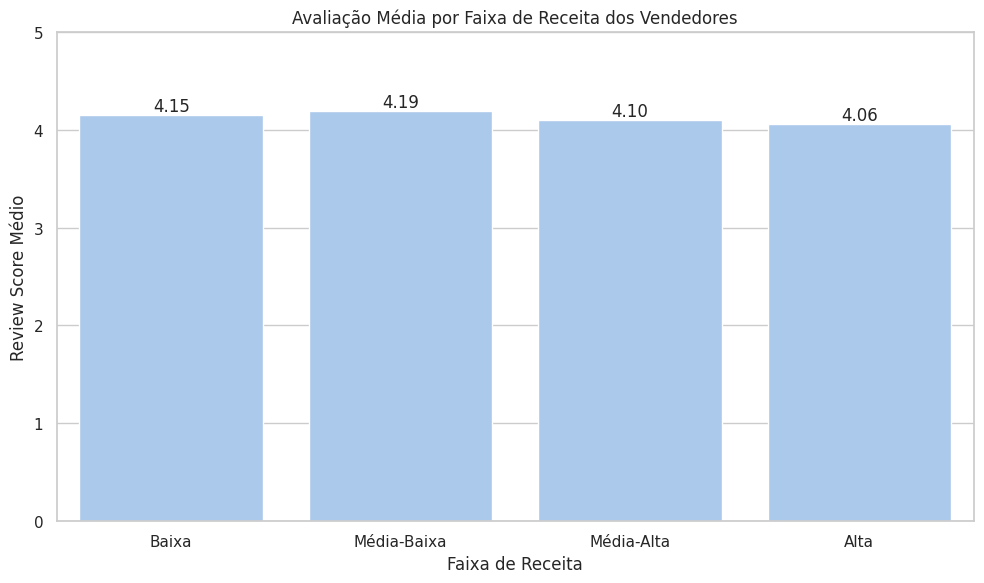

In [32]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=resumo_faixas.reset_index(),
    x="faixa_receita",
    y="review_medio"
)

plt.title("Avaliação Média por Faixa de Receita dos Vendedores")
plt.xlabel("Faixa de Receita")
plt.ylabel("Review Score Médio")
plt.ylim(0, 5)

for i, v in enumerate(resumo_faixas["review_medio"].values):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

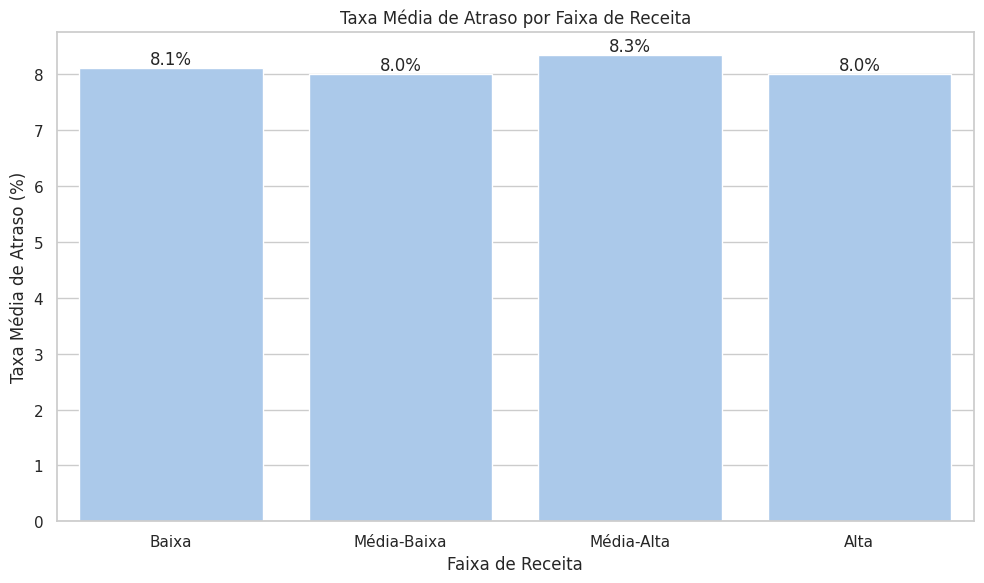

In [33]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=resumo_faixas.reset_index(),
    x="faixa_receita",
    y="taxa_atraso_media"
)

plt.title("Taxa Média de Atraso por Faixa de Receita")
plt.xlabel("Faixa de Receita")
plt.ylabel("Taxa Média de Atraso (%)")

for i, v in enumerate(resumo_faixas["taxa_atraso_media"].values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

Insight: o agrupamento por faixas de receita permite comparar perfis de vendedores sem focar apenas em casos individuais. Essa etapa ajuda a observar se sellers mais rentáveis conseguem manter qualidade de serviço e eficiência operacional.

## 10. Principais insights da análise

A análise dos vendedores da base Olist mostra que o desempenho não depende apenas de faturamento. Os sellers com maior receita e volume de pedidos não necessariamente apresentam a melhor eficiência logística ou a melhor percepção do cliente.

Os rankings mostram concentração de receita e volume em um grupo pequeno de vendedores, o que sugere assimetria operacional típica de marketplaces. Já os indicadores de avaliação e logística mostram que crescimento operacional não garante, por si só, excelência na experiência do cliente.

Além disso, as correlações indicam que atraso e tempo de entrega têm relação relevante com a nota média dos vendedores. Em outras palavras, a sustentabilidade da performance comercial depende do equilíbrio entre escala, operação e satisfação.

## 11. Validação da conclusão

In [34]:
validacao = resumo_faixas[[
    "receita_media",
    "pedidos_medios",
    "review_medio",
    "entrega_media",
    "taxa_atraso_media"
]].copy()

validacao

,receita_media,pedidos_medios,review_medio,entrega_media,taxa_atraso_media
faixa_receita,,,,,
Baixa,141.35,1.80,4.15,11.19,8.11
Média-Baixa,615.13,5.59,4.19,11.17,8.01
Média-Alta,"2,165.53",15.37,4.10,12.02,8.34
Alta,"18,204.14",111.12,4.06,12.30,8.01


Validação: ao comparar as faixas de receita, observa-se que o desempenho comercial precisa ser analisado junto aos indicadores operacionais. A análise valida que vendedores com maior receita média também possuem maior escala de pedidos, mas a qualidade dessa operação deve ser acompanhada por atraso, tempo de entrega e avaliação média.

Assim, a conclusão do notebook se sustenta: vendedores mais fortes em faturamento não devem ser avaliados apenas pela receita, mas pelo equilíbrio entre resultado financeiro, capacidade operacional e experiência do cliente.

## 12. Conclusão final

A análise individual de vendedores mostrou que o ecossistema da Olist possui forte concentração de receita e pedidos em poucos sellers. No entanto, o desempenho de um vendedor não pode ser resumido apenas ao faturamento. Indicadores de logística e satisfação do cliente foram essenciais para complementar a leitura dos resultados.

Como proposta de valor para o negócio, esse tipo de análise pode apoiar estratégias de acompanhamento de sellers, definição de faixas de performance e ações para redução de atraso e melhoria da experiência do consumidor.